In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
file_path = 'data/milan_data/'
file_name = '100genes_sparsity025_wildtype_timeseries'
num_file = 22
data_list = []
for i in range(22):
    data_list.append(pd.read_csv(file_path + file_name + f'{i}.tsv', sep='\t'))

In [55]:
cols_to_plot = data_list[0].columns[1:]
len(cols_to_plot)

100

In [84]:
data_0 = data_list[0][cols_to_plot]
variances = data_0.var()
varied_cols = data_0.loc[:, variances > 0.005]
chosen_columns = varied_cols.columns

In [120]:
print(chosen_columns)

Index(['Node_0', 'Node_4', 'Node_6', 'Node_8', 'Node_10', 'Node_11', 'Node_15',
       'Node_19', 'Node_20', 'Node_23', 'Node_27', 'Node_28', 'Node_29',
       'Node_32', 'Node_35', 'Node_40', 'Node_41', 'Node_42', 'Node_46',
       'Node_48', 'Node_49', 'Node_53', 'Node_54', 'Node_55', 'Node_56',
       'Node_59', 'Node_61', 'Node_63', 'Node_64', 'Node_66', 'Node_67',
       'Node_71', 'Node_73', 'Node_74', 'Node_75', 'Node_77', 'Node_82',
       'Node_83', 'Node_86', 'Node_91', 'Node_93', 'Node_97', 'Node_99'],
      dtype='object')


/tmp/ipykernel_21208/386742810.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6,6))


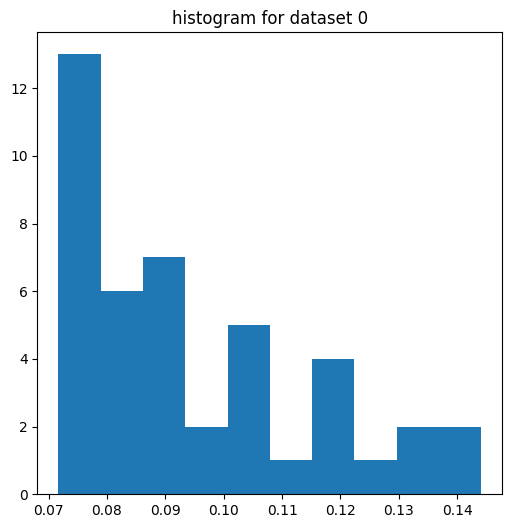

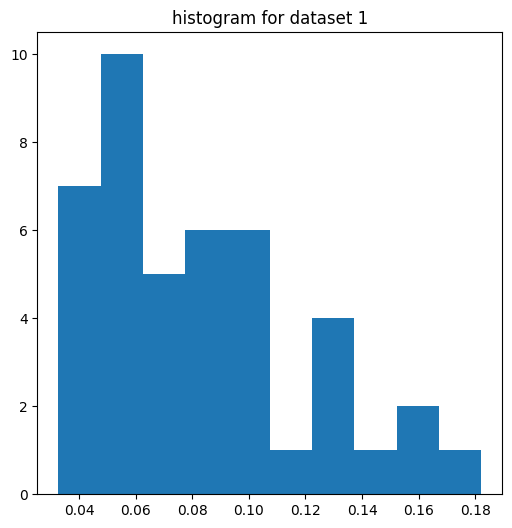

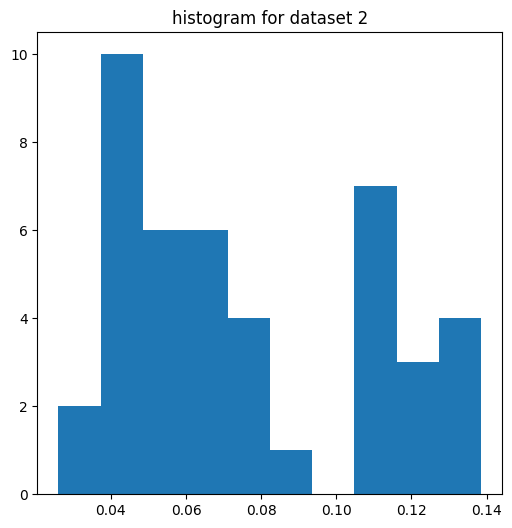

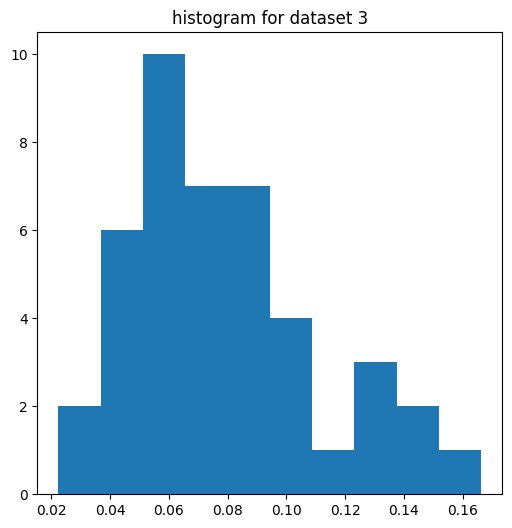

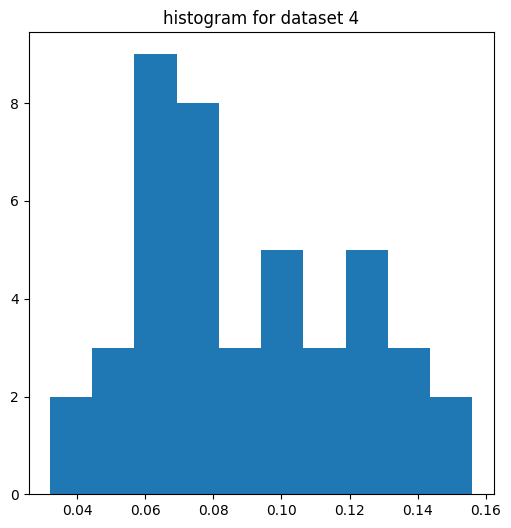

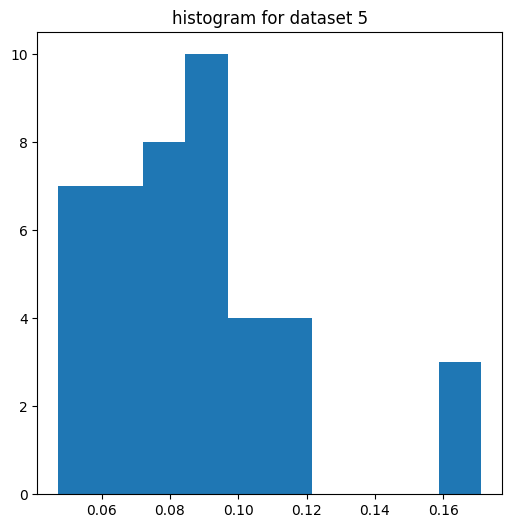

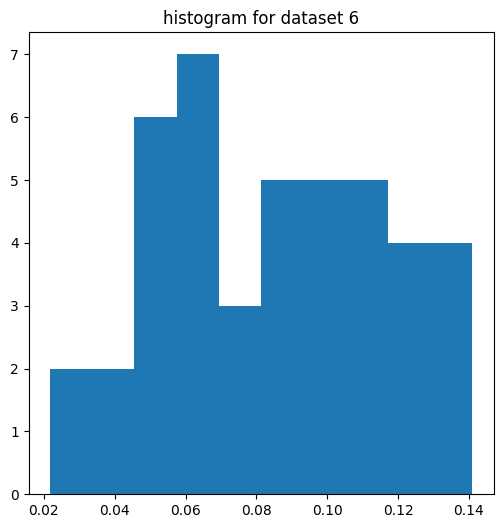

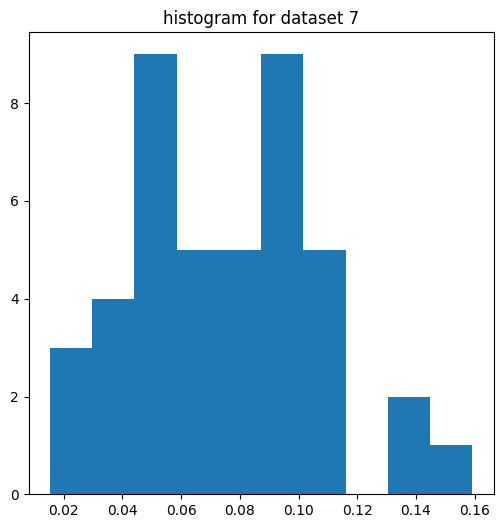

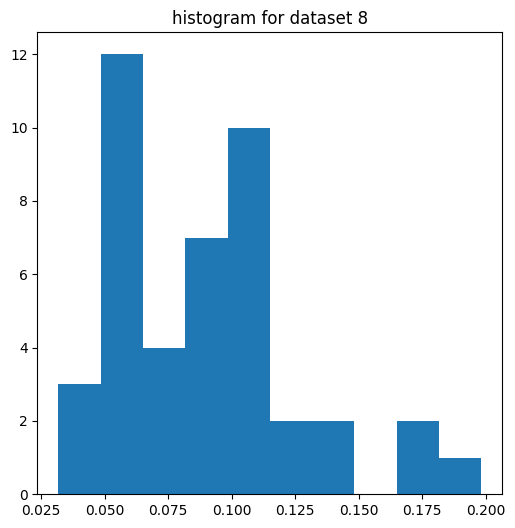

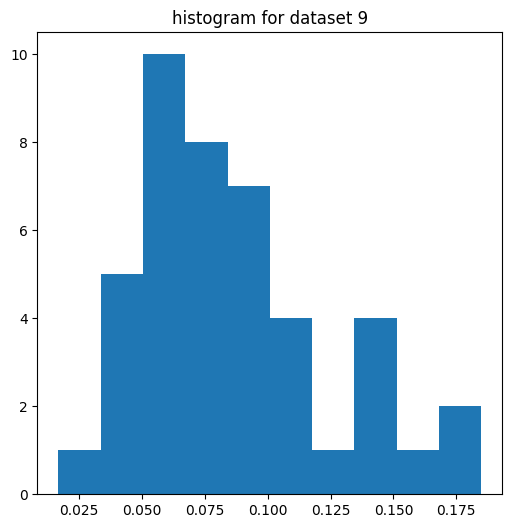

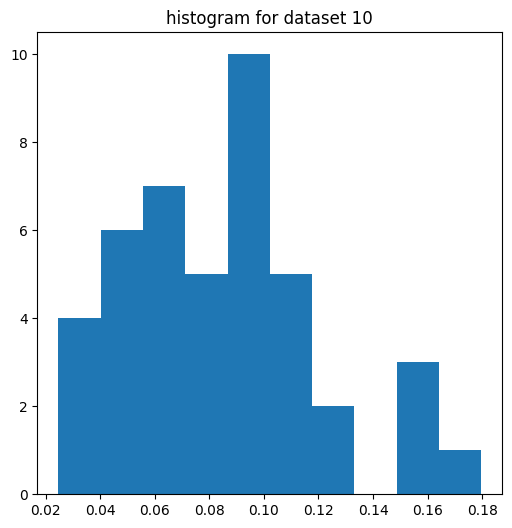

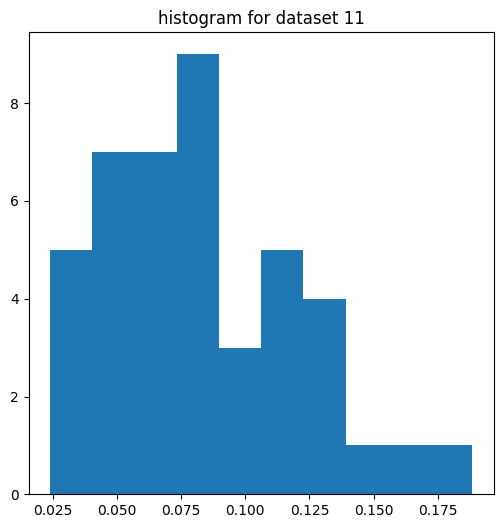

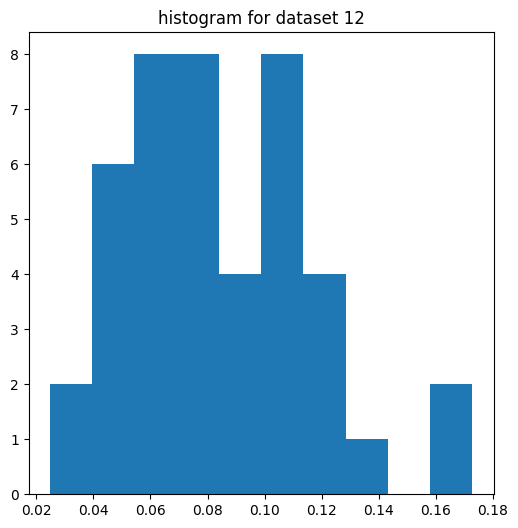

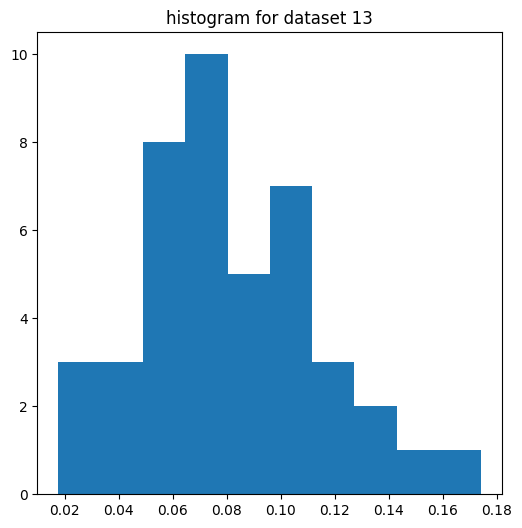

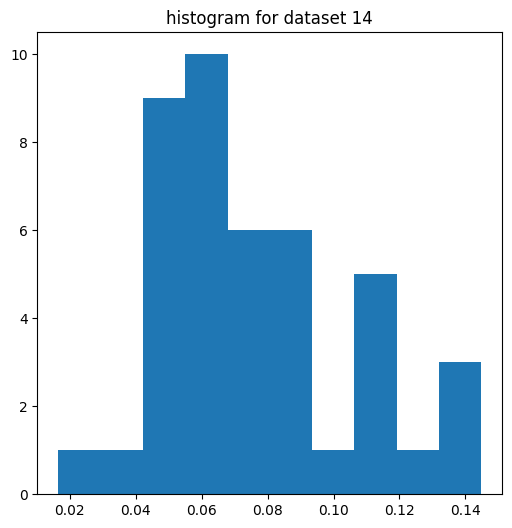

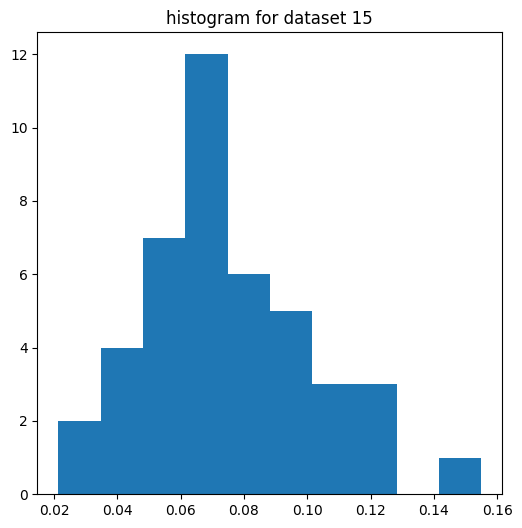

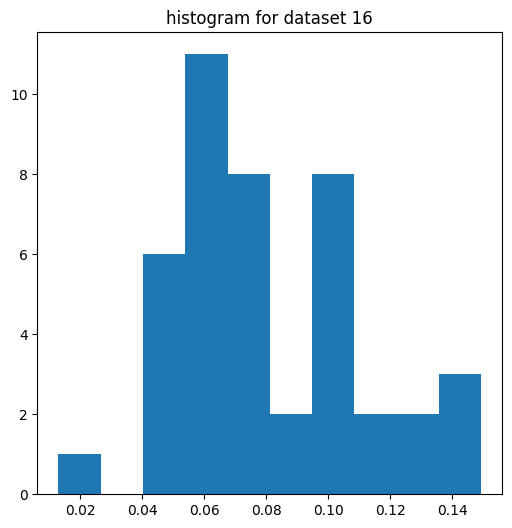

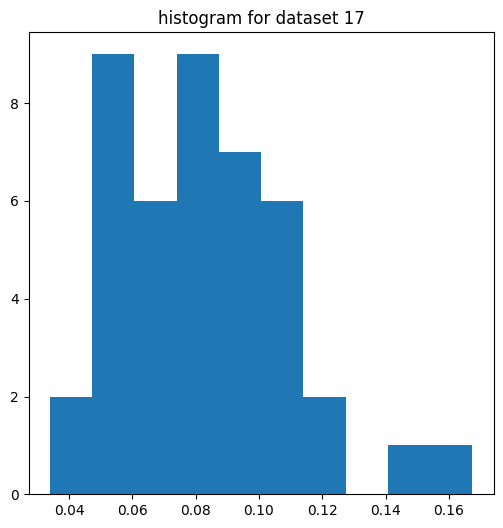

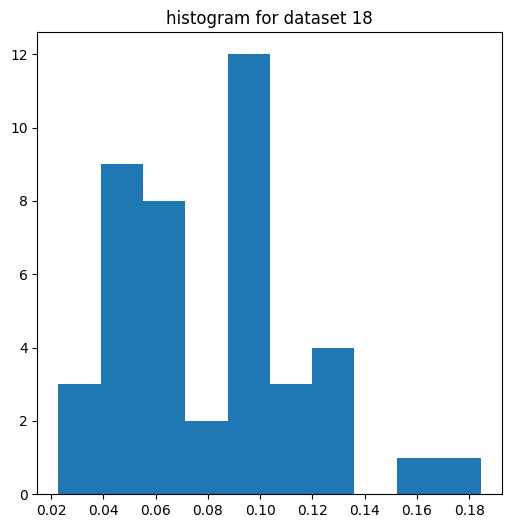

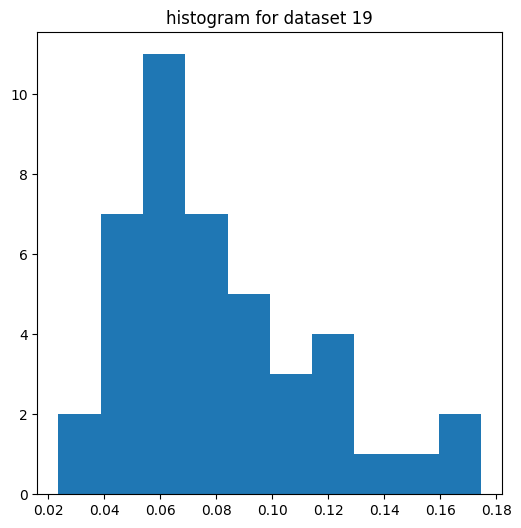

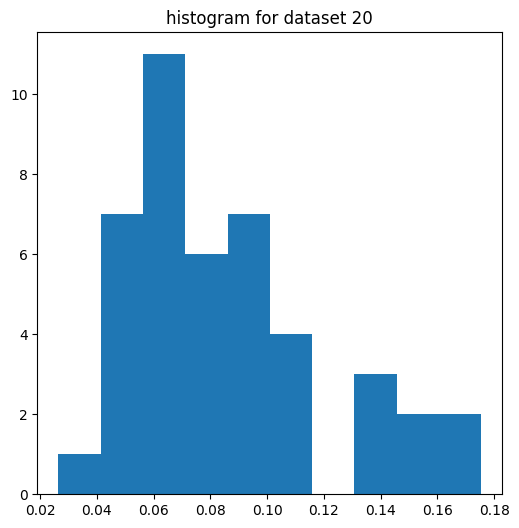

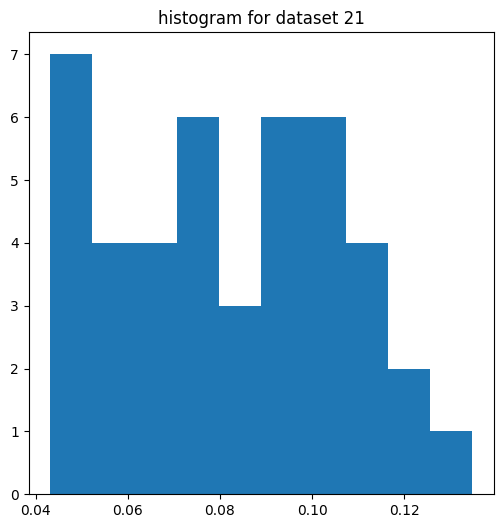

In [116]:
varied_column = set()
plt.figure(figsize=(6,6))
plt.hist(varied_cols.std())
plt.title('histogram for dataset 0')
for i in range(len(data_list)-1):
    data_0 = data_list[i+1][chosen_columns]
    variances = data_0.std()
    plt.figure(figsize=(6,6))
    plt.hist(variances)
    plt.title(f'histogram for dataset {i+1}')

Based on these histograms we choose datasets 21 and 4 to add to dataset 0



Let's graph these together to make sure there's variance in them

In [117]:
chosen_data_list = []
chosen_data_list.append(data_list[0][chosen_columns])
chosen_data_list.append(data_list[4][chosen_columns])
chosen_data_list.append(data_list[21][chosen_columns])
smooth_list = []
window = 10
for data in chosen_data_list:
    
    smooth_list.append(data.rolling(window=window, center=True, min_periods=1).mean())

<Figure size 1400x1000 with 0 Axes>

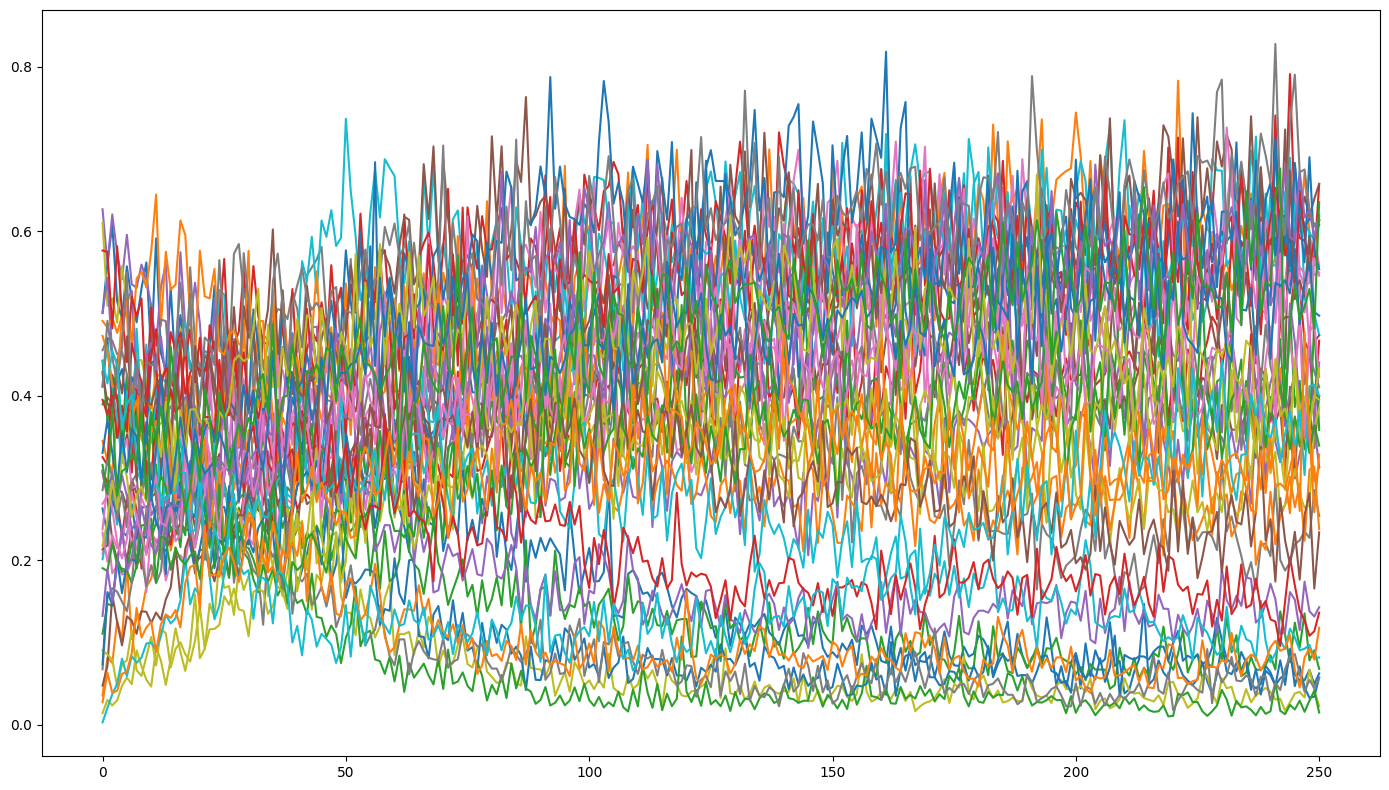

<Figure size 1400x1000 with 0 Axes>

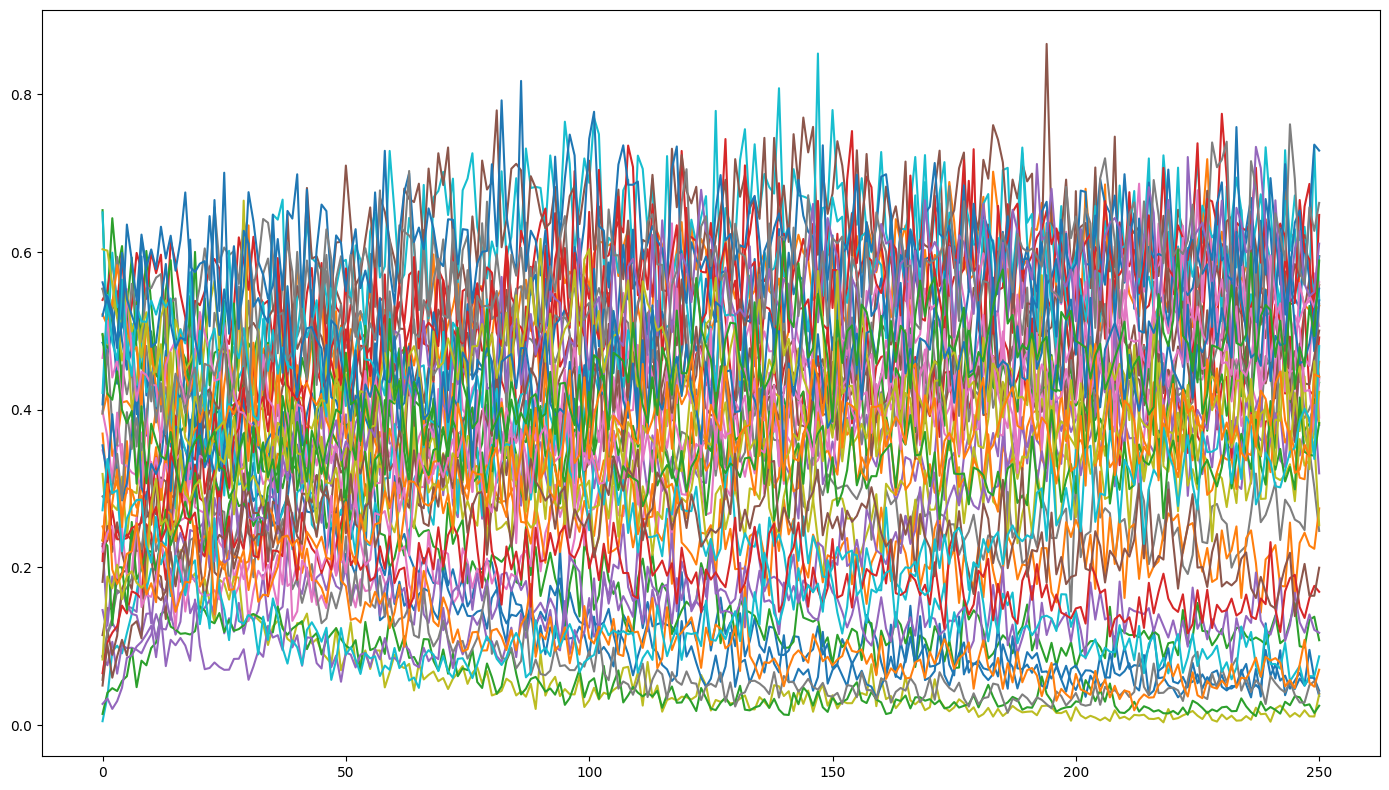

<Figure size 1400x1000 with 0 Axes>

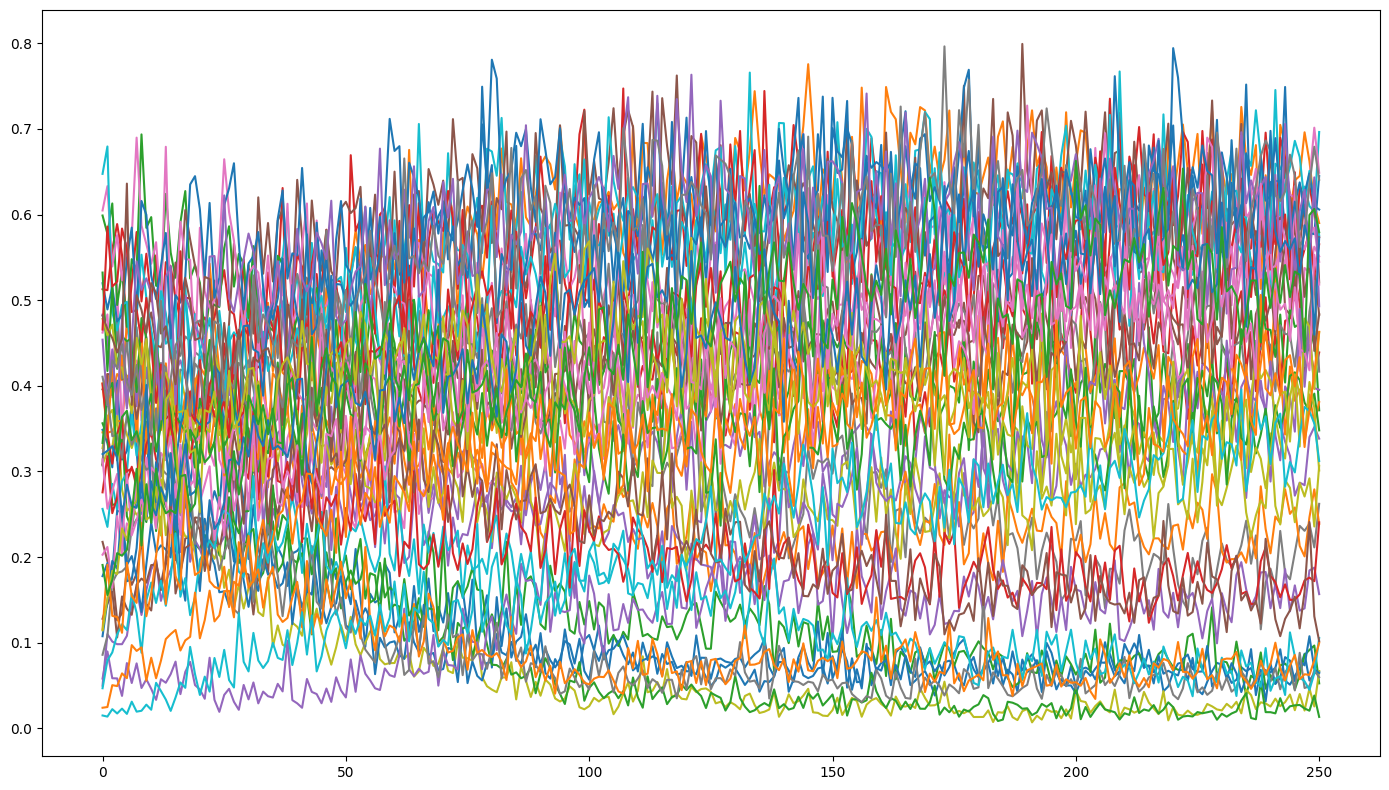

<Figure size 1400x800 with 0 Axes>

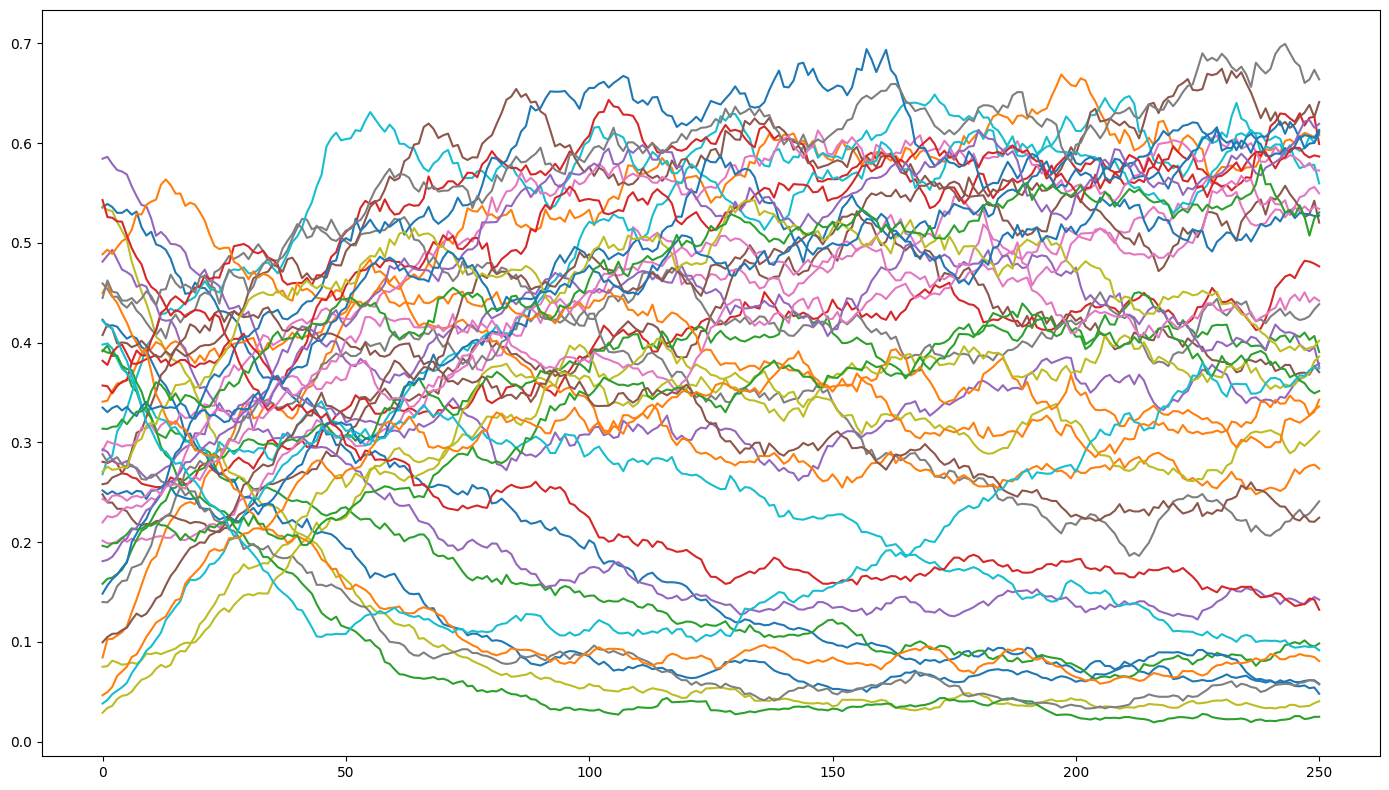

<Figure size 1400x800 with 0 Axes>

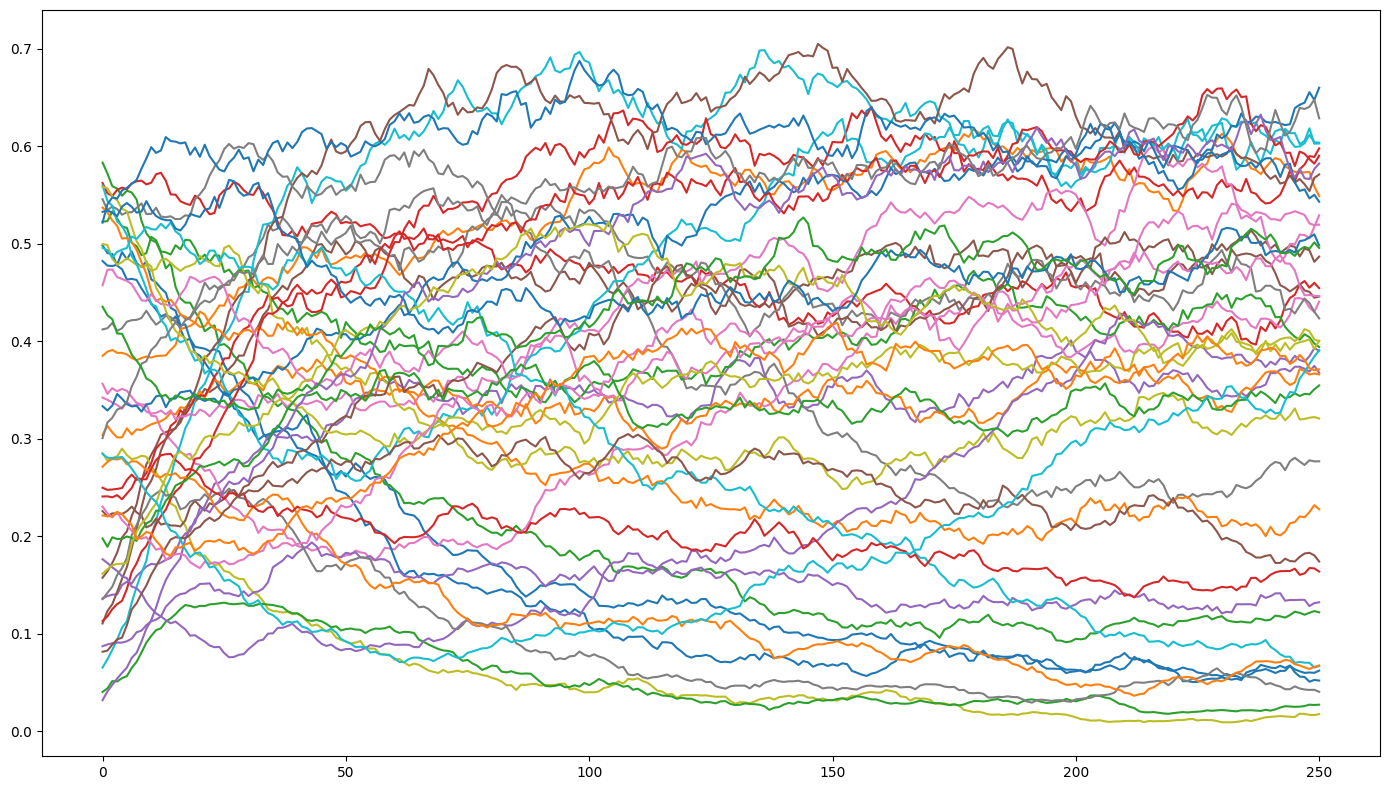

<Figure size 1400x800 with 0 Axes>

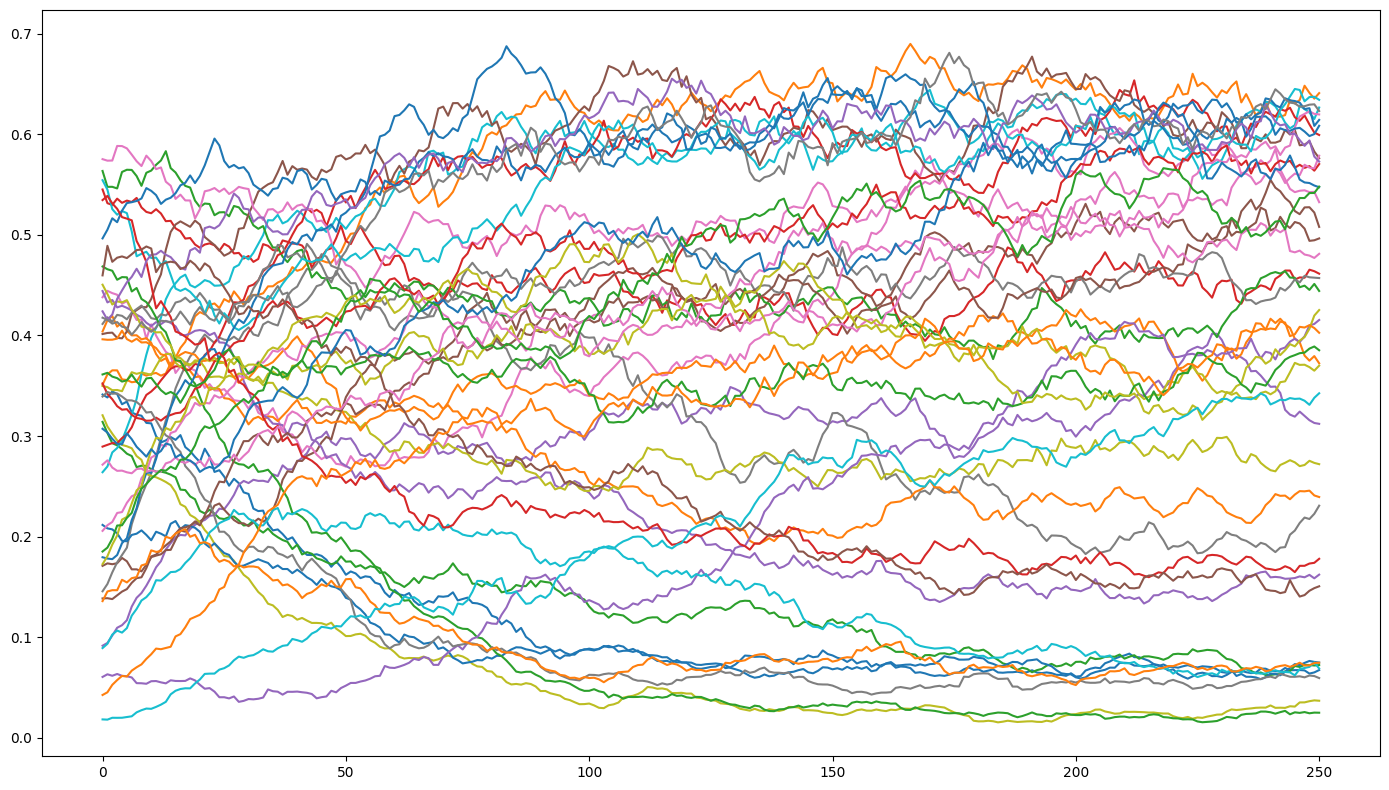

In [118]:
for data in chosen_data_list:
    plt.figure(figsize=(14,10))
    data.plot(figsize=(14,8), legend=False)
    plt.tight_layout()
    plt.show()
    
    
for data in smooth_list:
    plt.figure(figsize=(14,8))
    data.plot(figsize=(14,8), legend=False)
    plt.tight_layout()
    plt.show()

In [119]:
from scipy.io import loadmat
from scipy.io import savemat

# to save as .mat, we need to have a dictionary

save_dict = {'X0': chosen_data_list[0].to_numpy().T,
             'X4': chosen_data_list[1].to_numpy().T,
             'X9': chosen_data_list[2].to_numpy().T,
             'dt1': np.array([[0.1]])}
savemat('milan0421_fullres.mat', save_dict)

smooth_dict = {'X0': smooth_list[0].to_numpy().T,
             'X4': smooth_list[1].to_numpy().T,
             'X9': smooth_list[2].to_numpy().T,
             'dt1': np.array([[0.5]])}
savemat('milan0421_smooth_fullres.mat', smooth_dict)